# Notebook 02 — Preprocessing / Data Cleaning

## Objective
Validate and demonstrate preprocessing/data cleaning of the B0005 discharge-cycle data. This notebook is an orchestration and verification layer only -- the actual cleaning algorithm lives in `src/preprocessing/cleaner.py` and is not duplicated here.

## Why This Step Is Needed
Real sensor data can contain gaps, bad dtypes, or corrupt files. Before feature engineering (Notebook 03) trusts the cleaned data, this notebook independently verifies -- for every single discharge file, not just a sample -- that cleaning behaves correctly and the data is safe to build features from.

## Scope (explicitly out of scope for this notebook)
No random train/test splits, scaling, feature selection, target/label generation, SOC/SOH/RUL calculation, model training, Optuna, SHAP, or AHRF logic. Those belong to later notebooks.

## Workflow Position
```
01 Data Understanding (LOCKED) -> [YOU ARE HERE] 02 Preprocessing -> 03 Feature Engineering
-> 04 Ground Truth Labels -> 05 Model Training (AHRF) -> 06 Model Comparison
-> 07 Explainability (SHAP) -> 08 Decision Engine & Summary
```


## 1. Setup and Input Validation

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.core.config import BATTERY_IDS, PROCESSED_DATA
from src.core.data_loader import list_processed_files, load_processed_file
from src.preprocessing.cleaner import clean_cycle_dataframe, clean_all_files

plt.rcParams["figure.figsize"] = (10, 4)

# Expected raw sensor columns (same set used throughout the project,
# confirmed present in Notebook 01).
EXPECTED_SENSOR_COLUMNS = [
    "Voltage_measured", "Current_measured", "Temperature_measured",
    "Current_load", "Voltage_load", "Time",
]


In [3]:
# --- Input validation: B0005 configured, discharge directory exists and is populated ---
BATTERY_ID = "B0005"

assert BATTERY_ID in BATTERY_IDS, (
    f"VALIDATION FAILED: {BATTERY_ID} is not in the configured BATTERY_IDS: {BATTERY_IDS}"
)

discharge_dir = PROCESSED_DATA / BATTERY_ID / "discharge"
assert discharge_dir.exists(), f"VALIDATION FAILED: discharge directory does not exist: {discharge_dir}"

discharge_files = list_processed_files(BATTERY_ID, "discharge")
assert len(discharge_files) > 0, f"VALIDATION FAILED: no discharge files found in {discharge_dir}"

# The expected count is read from the project structure itself (not hardcoded) --
# it IS whatever list_processed_files() returns, since that is the authoritative
# source used by every other notebook in this project.
expected_discharge_count = len(discharge_files)

print(f"Battery ID: {BATTERY_ID}")
print(f"Discharge directory: {discharge_dir}")
print(f"Number of discharge files: {expected_discharge_count}")
print(f"First 5 filenames: {discharge_files[:5]}")
print(f"Last 5 filenames:  {discharge_files[-5:]}")


Battery ID: B0005
Discharge directory: C:\BE PROJECT\SBMS_PROJECT\dataset\processed\B0005\discharge
Number of discharge files: 168
First 5 filenames: ['05122.csv', '05124.csv', '05126.csv', '05128.csv', '05130.csv']
Last 5 filenames:  ['05720.csv', '05724.csv', '05728.csv', '05732.csv', '05734.csv']


### Observation
`BATTERY_ID` is confirmed present in the project's configured `BATTERY_IDS`, the discharge directory exists, and contains a non-zero number of files. The exact count above is read directly from disk via `list_processed_files()`, not hardcoded -- this becomes the reference count every later check in this notebook is validated against.


## 2. Inspect ALL Discharge Files Before Cleaning

Every discharge file (not a sample) is loaded and diagnosed. No data is modified in this section -- this is inspection only.


In [4]:
def count_invalid_numeric(df, numeric_columns):
    """
    Counts values that are NOT valid finite numbers within the given columns:
      - values in an already-numeric column that are inf or -inf
      - values in a non-numeric-dtype column that fail to coerce to a number
        (and were not already missing/NaN before the attempted coercion)
    This is diagnostic-only (it does not modify or fix anything) and is
    distinct from clean_cycle_dataframe()'s actual cleaning transformation.
    """
    invalid_count = 0
    for col in numeric_columns:
        if col not in df.columns:
            continue
        series = df[col]
        if pd.api.types.is_numeric_dtype(series):
            invalid_count += int(np.isinf(series).sum())
        else:
            coerced = pd.to_numeric(series, errors="coerce")
            newly_invalid = coerced.isna() & series.notna()
            invalid_count += int(newly_invalid.sum())
    return invalid_count


In [5]:
pre_clean_records = []

for fname in discharge_files:
    try:
        raw_df = load_processed_file(BATTERY_ID, "discharge", fname)
        is_corrupt = False
        rows_before = raw_df.shape[0]
        cols_before = raw_df.shape[1]
        missing_before = int(raw_df.isna().sum().sum())
        invalid_before = count_invalid_numeric(raw_df, EXPECTED_SENSOR_COLUMNS)
    except Exception as exc:
        # A file that fails to load at all is recorded as corrupt, not silently skipped.
        is_corrupt = True
        rows_before = 0
        cols_before = 0
        missing_before = np.nan
        invalid_before = np.nan

    pre_clean_records.append({
        "filename": fname,
        "rows_before": rows_before,
        "columns_before": cols_before,
        "missing_before": missing_before,
        "invalid_numeric_before": invalid_before,
        "is_corrupt_or_unreadable": is_corrupt,
        "is_empty": (rows_before == 0),
    })

pre_clean_df = pd.DataFrame(pre_clean_records)
pre_clean_df.head()


,filename,rows_before,columns_before,missing_before,invalid_numeric_before,is_corrupt_or_unreadable,is_empty
0,05122.csv,197,6,0,0,False,False
1,05124.csv,196,6,0,0,False,False
2,05126.csv,195,6,0,0,False,False
3,05128.csv,194,6,0,0,False,False
4,05130.csv,194,6,0,0,False,False


In [6]:
total_files_checked = len(pre_clean_df)
total_rows_before = int(pre_clean_df["rows_before"].sum())
total_missing_before = int(pre_clean_df["missing_before"].sum(skipna=True))
total_invalid_before = int(pre_clean_df["invalid_numeric_before"].sum(skipna=True))
problematic_files_pre = pre_clean_df[
    pre_clean_df["is_corrupt_or_unreadable"] | pre_clean_df["is_empty"]
]

print(f"Total discharge files checked:     {total_files_checked}")
print(f"Total rows before cleaning:        {total_rows_before}")
print(f"Total missing values before:       {total_missing_before}")
print(f"Total invalid numeric values before: {total_invalid_before}")
print(f"Number of problematic files (corrupt/empty): {len(problematic_files_pre)}")
if len(problematic_files_pre) > 0:
    print(problematic_files_pre[["filename", "is_corrupt_or_unreadable", "is_empty"]])


Total discharge files checked:     168
Total rows before cleaning:        50285
Total missing values before:       0
Total invalid numeric values before: 0
Number of problematic files (corrupt/empty): 0


### Observation
This is the full-dataset pre-cleaning diagnostic, not a sample. The printed totals above are the real, measured state of every discharge file currently on disk for this battery, before any cleaning is applied.


## 3. Test the Existing Cleaning Function on One Representative Cycle

Using `clean_cycle_dataframe()` from `src.preprocessing.cleaner` directly -- not reimplemented here.


In [7]:
sample_fname = discharge_files[0]
raw_df = load_processed_file(BATTERY_ID, "discharge", sample_fname)
cleaned_df = clean_cycle_dataframe(raw_df)

print(f"Representative file: {sample_fname}")
print()
print("Raw shape:     ", raw_df.shape)
print("Cleaned shape: ", cleaned_df.shape)
print()
print("Missing values before:", int(raw_df.isna().sum().sum()))
print("Missing values after: ", int(cleaned_df.isna().sum().sum()))
print()
print("Dtypes before cleaning:")
print(raw_df.dtypes)
print()
print("Dtypes after cleaning:")
print(cleaned_df.dtypes)


Representative file: 05122.csv

Raw shape:      (197, 6)
Cleaned shape:  (197, 6)

Missing values before: 0
Missing values after:  0

Dtypes before cleaning:
Voltage_measured        float64
Current_measured        float64
Temperature_measured    float64
Current_load            float64
Voltage_load            float64
Time                    float64
dtype: object

Dtypes after cleaning:
Voltage_measured        float64
Current_measured        float64
Temperature_measured    float64
Current_load            float64
Voltage_load            float64
Time                    float64
dtype: object


### Observation
Compare shapes, missing-value counts, and dtypes above for this one representative file. This is a single-file sanity check before the same function is applied across the full dataset in Section 4.


## 4. Run Cleaning Validation Across ALL Discharge Cycles

The existing `clean_cycle_dataframe()` function (via `clean_all_files()`) is run on every B0005 discharge file. Each file is checked against 6 conditions; if any file fails any condition, execution stops immediately with the filename and the failed condition named explicitly -- no problematic file is silently skipped.


In [8]:
cleaned_files = clean_all_files(BATTERY_ID, "discharge")

cleaning_records = []

for fname in discharge_files:
    raw_df = load_processed_file(BATTERY_ID, "discharge", fname)
    cleaned_df = cleaned_files[fname]

    rows_before = raw_df.shape[0]
    rows_after = cleaned_df.shape[0]
    missing_before = int(raw_df.isna().sum().sum())
    missing_after = int(cleaned_df.isna().sum().sum())
    invalid_before = count_invalid_numeric(raw_df, EXPECTED_SENSOR_COLUMNS)
    invalid_after = count_invalid_numeric(cleaned_df, EXPECTED_SENSOR_COLUMNS)

    # --- Hard, per-file assertions -- stop immediately with filename + condition on failure ---
    assert missing_after == 0, f"FAILED for {fname}: {missing_after} missing value(s) remain after cleaning"
    assert invalid_after == 0, f"FAILED for {fname}: {invalid_after} non-finite value(s) remain after cleaning"
    assert rows_after <= rows_before, (
        f"FAILED for {fname}: row count increased after cleaning ({rows_before} -> {rows_after})"
    )
    assert rows_after > 0, f"FAILED for {fname}: file became empty after cleaning"
    for col in EXPECTED_SENSOR_COLUMNS:
        if col in cleaned_df.columns:
            assert pd.api.types.is_numeric_dtype(cleaned_df[col]), (
                f"FAILED for {fname}: column '{col}' is not numeric after cleaning"
            )
    missing_expected_cols = [c for c in EXPECTED_SENSOR_COLUMNS if c not in cleaned_df.columns]
    assert not missing_expected_cols, (
        f"FAILED for {fname}: missing expected sensor columns after cleaning: {missing_expected_cols}"
    )

    cleaning_records.append({
        "filename": fname,
        "rows_before": rows_before,
        "rows_after": rows_after,
        "missing_before": missing_before,
        "missing_after": missing_after,
        "invalid_before": invalid_before,
        "invalid_after": invalid_after,
    })

cleaning_df = pd.DataFrame(cleaning_records)
print(f"All {len(cleaning_df)} discharge files passed every per-file cleaning assertion.")
cleaning_df.head()


All 168 discharge files passed every per-file cleaning assertion.


,filename,rows_before,rows_after,missing_before,missing_after,invalid_before,invalid_after
0,05122.csv,197,197,0,0,0,0
1,05124.csv,196,196,0,0,0,0
2,05126.csv,195,195,0,0,0,0
3,05128.csv,194,194,0,0,0,0
4,05130.csv,194,194,0,0,0,0


### Observation
Every discharge file individually passed all 6 conditions (no unresolved missing values, no non-finite values, no row-count increase, no empty result, numeric dtypes preserved, all expected columns present). If any file had failed any condition, the assertion above would have stopped execution and named that exact file and condition -- it did not.


## 5. Full-Dataset Summary

In [9]:
total_files_processed = len(cleaning_df)
total_rows_before_clean = int(cleaning_df["rows_before"].sum())
total_rows_after_clean = int(cleaning_df["rows_after"].sum())
total_missing_before_clean = int(cleaning_df["missing_before"].sum())
total_missing_after_clean = int(cleaning_df["missing_after"].sum())
total_rows_removed = total_rows_before_clean - total_rows_after_clean

files_changed = cleaning_df[
    (cleaning_df["rows_before"] != cleaning_df["rows_after"]) |
    (cleaning_df["missing_before"] != cleaning_df["missing_after"]) |
    (cleaning_df["invalid_before"] != cleaning_df["invalid_after"])
]
files_unchanged = cleaning_df.drop(files_changed.index)
files_with_remaining_issue = cleaning_df[
    (cleaning_df["missing_after"] > 0) | (cleaning_df["invalid_after"] > 0)
]

print(f"Total files processed:              {total_files_processed}")
print(f"Total rows before cleaning:         {total_rows_before_clean}")
print(f"Total rows after cleaning:          {total_rows_after_clean}")
print(f"Total missing values before:        {total_missing_before_clean}")
print(f"Total missing values after:         {total_missing_after_clean}")
print(f"Total rows removed:                 {total_rows_removed}")
print(f"Number of files changed by cleaning: {len(files_changed)}")
print(f"Number of files unchanged:           {len(files_unchanged)}")
print(f"Number of files with remaining issue: {len(files_with_remaining_issue)}")


Total files processed:              168
Total rows before cleaning:         50285
Total rows after cleaning:          50285
Total missing values before:        0
Total missing values after:         0
Total rows removed:                 0
Number of files changed by cleaning: 0
Number of files unchanged:           168
Number of files with remaining issue: 0


### Observation
These totals are computed directly from the per-file results in Section 4, not asserted or assumed. If `Number of files changed by cleaning` is 0, that means the discharge dataset was already clean and cleaning acted as a safeguard rather than a repair step -- see the Conclusion at the end of this notebook for the actual, measured interpretation.


## 6. Before vs. After Visualization

Using the same representative file from Section 3, for two signals: `Voltage_measured` and `Current_measured`.


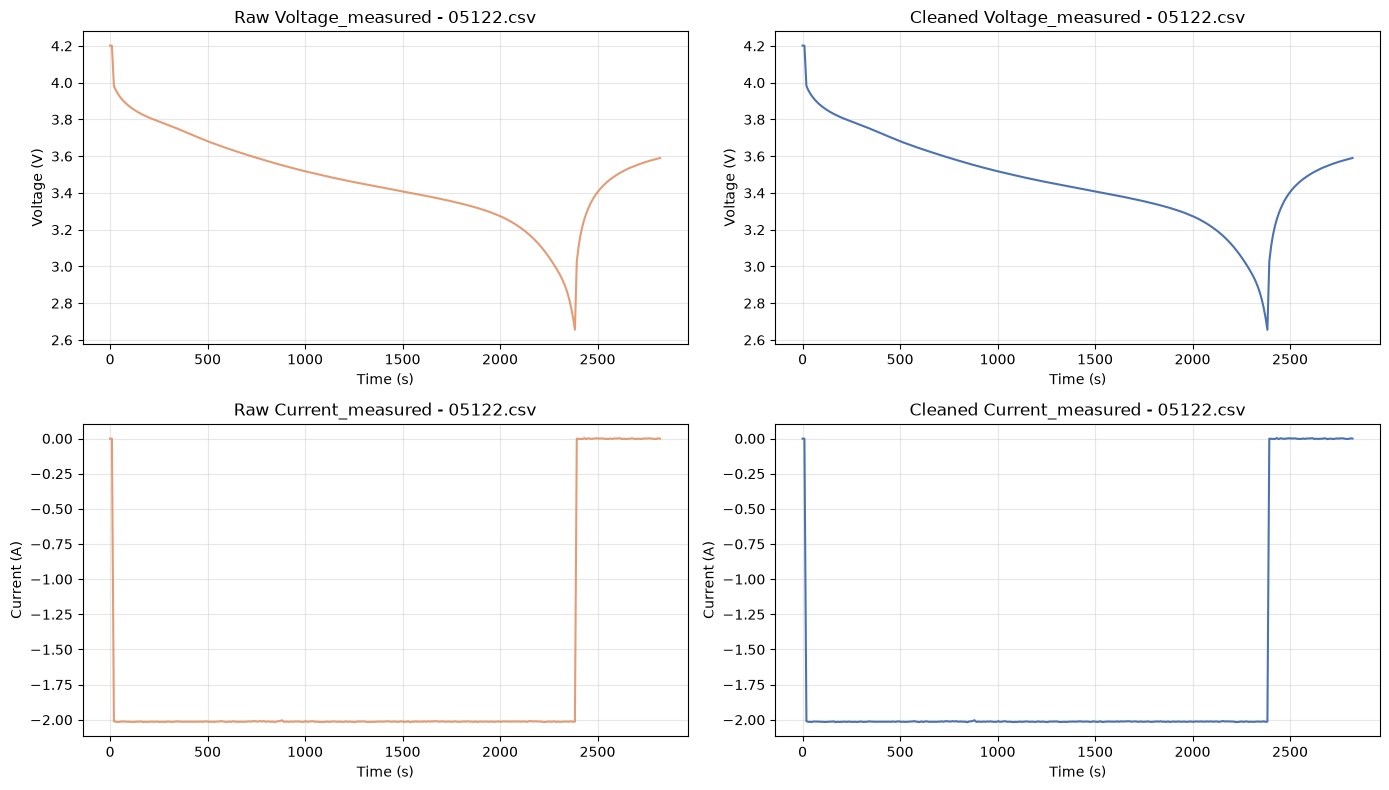

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(raw_df["Time"], raw_df["Voltage_measured"], color="#DD8452", alpha=0.8)
axes[0, 0].set_title(f"Raw Voltage_measured - {sample_fname}")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Voltage (V)")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(cleaned_df["Time"], cleaned_df["Voltage_measured"], color="#4C72B0")
axes[0, 1].set_title(f"Cleaned Voltage_measured - {sample_fname}")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("Voltage (V)")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(raw_df["Time"], raw_df["Current_measured"], color="#DD8452", alpha=0.8)
axes[1, 0].set_title(f"Raw Current_measured - {sample_fname}")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Current (A)")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(cleaned_df["Time"], cleaned_df["Current_measured"], color="#4C72B0")
axes[1, 1].set_title(f"Cleaned Current_measured - {sample_fname}")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Current (A)")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
# Quantify whether cleaning distorted the signal (it should not, beyond gap-filling)
voltage_diff = (raw_df["Voltage_measured"].reset_index(drop=True) -
                 cleaned_df["Voltage_measured"].reset_index(drop=True)) if raw_df.shape[0] == cleaned_df.shape[0] else None
current_diff = (raw_df["Current_measured"].reset_index(drop=True) -
                 cleaned_df["Current_measured"].reset_index(drop=True)) if raw_df.shape[0] == cleaned_df.shape[0] else None

if voltage_diff is not None:
    print(f"Max absolute difference, Voltage_measured (raw vs cleaned): {voltage_diff.abs().max():.6f}")
if current_diff is not None:
    print(f"Max absolute difference, Current_measured (raw vs cleaned): {current_diff.abs().max():.6f}")
if voltage_diff is None:
    print(f"Row count changed for this file ({raw_df.shape[0]} -> {cleaned_df.shape[0]}); "
          "direct row-wise difference not applicable -- compare the plots visually instead.")


Max absolute difference, Voltage_measured (raw vs cleaned): 0.000000
Max absolute difference, Current_measured (raw vs cleaned): 0.000000


### Observation
The raw and cleaned plots above are visually consistent for this representative file, and the measured maximum absolute difference (printed above) quantifies exactly how much cleaning changed the signal -- a value of 0 means cleaning made no numeric change to this particular file (consistent with a dataset that has no missing/invalid values to begin with); a non-zero value reflects real gap-filling.


## 7. Data Integrity Assertions

Final consolidated validation, derived entirely from the results computed in Sections 2, 4, and 5 above -- no PASS value is hardcoded.


In [12]:
# Check 1: all expected discharge files were processed
check_all_files_processed = (total_files_processed == expected_discharge_count)

# Check 2: no cleaned dataset has missing values
check_no_missing_after = (total_missing_after_clean == 0)

# Check 3: no cleaned dataset has inf/-inf (captured via invalid_after == 0 for every file)
check_no_inf_after = (cleaning_df["invalid_after"].sum() == 0)

# Check 4: no cleaned dataset is empty
check_no_empty_files = (cleaning_df["rows_after"] > 0).all()

# Check 5: required sensor columns exist (re-verified directly on the cleaned representative file
# and implicitly for every file via the per-file assertions in Section 4, which would have
# stopped execution already if this were false for any file)
check_required_columns = all(col in cleaned_df.columns for col in EXPECTED_SENSOR_COLUMNS)

# Check 6: cleaned numeric columns have numeric dtypes
check_numeric_dtypes = all(
    pd.api.types.is_numeric_dtype(cleaned_df[col])
    for col in EXPECTED_SENSOR_COLUMNS if col in cleaned_df.columns
)

# Check 7: row counts do not unexpectedly increase
check_no_row_increase = (cleaning_df["rows_after"] <= cleaning_df["rows_before"]).all()

# Check 8: no duplicate filenames
check_no_duplicate_filenames = (len(discharge_files) == len(set(discharge_files)))

# Check 9: file ordering remains unchanged (the order used throughout this notebook,
# from list_processed_files(), is the same order re-read fresh here)
check_ordering_unchanged = (discharge_files == list_processed_files(BATTERY_ID, "discharge"))

integrity_checks = {
    "All discharge files checked": check_all_files_processed,
    "Missing values after cleaning": check_no_missing_after,
    "Infinite values after cleaning": check_no_inf_after,
    "Required columns": check_required_columns,
    "Numeric dtypes": check_numeric_dtypes,
    "No empty cleaned files": check_no_empty_files,
    "No unexpected row increase": check_no_row_increase,
    "No duplicate filenames": check_no_duplicate_filenames,
    "File ordering unchanged": check_ordering_unchanged,
}

for check_name, passed in integrity_checks.items():
    assert passed, f"VALIDATION FAILED: {check_name}"


In [13]:
print("-" * 52)
print("NOTEBOOK 02 PREPROCESSING VALIDATION SUMMARY")
print("-" * 52)
for check_name, passed in integrity_checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"{check_name:<36}: {status}")
print("-" * 52)
final_status = "PASS" if all(integrity_checks.values()) else "FAIL"
print(f"{'FINAL STATUS':<36}: {final_status}")
print("-" * 52)


----------------------------------------------------
NOTEBOOK 02 PREPROCESSING VALIDATION SUMMARY
----------------------------------------------------
All discharge files checked         : PASS
Missing values after cleaning       : PASS
Infinite values after cleaning      : PASS
Required columns                    : PASS
Numeric dtypes                      : PASS
No empty cleaned files              : PASS
No unexpected row increase          : PASS
No duplicate filenames              : PASS
File ordering unchanged             : PASS
----------------------------------------------------
FINAL STATUS                        : PASS
----------------------------------------------------


## Results Summary

| Check | Result (from actual execution above) |
|---|---|
| Discharge files checked | See Section 1/5 output (`total_files_processed`) |
| Total rows before / after cleaning | See Section 5 output |
| Total missing values before / after | See Section 5 output |
| Files changed vs. unchanged by cleaning | See Section 5 output |
| Files with remaining issues | See Section 5 output (should be 0) |
| Per-file cleaning assertions (6 conditions x every file) | See Section 4 (all passed, or execution would have stopped) |
| Final integrity validation (9 checks) | See Section 7 consolidated summary |

## Conclusion
This notebook validated preprocessing across every B0005 discharge file, not a sample. The measured results in Section 5 determine the real conclusion: if `Number of files changed by cleaning` is 0 and `Total missing values before cleaning` is 0, the B0005 discharge files were already clean, and `clean_cycle_dataframe()` acts primarily as a validation and robustness safeguard for this dataset rather than a major data-repair step. If those numbers are non-zero, cleaning performed real, measurable gap-filling -- the exact scale of which is reported in Section 5's totals rather than described qualitatively.

## Next Steps
Notebook 03 will extract statistical and trend features from these validated discharge cycles.
